# Model Interpretation - Part 3
## with Deep Explainers

Interpretation of deep learning models, with SHAP

[SHAP (SHapley Additive exPlanations)](https://github.com/shap/shap) is a game theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions (see papers for details and citations).

@Ricardo Almeida

Ricardo Almeida, using [Fashion MNIST](https://keras.io/api/datasets/fashion_mnist/) dataset

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

os.environ['USE_TF'] = '0' 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

import transformers

In [3]:
from keras import Input
from keras.datasets import fashion_mnist
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from keras.models import Sequential

In [4]:
shap.initjs()

## Natural language explanations

In [8]:
# load a transformers pipeline model
model = transformers.pipeline('sentiment-analysis', return_all_scores=True)

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/opt/anaconda3/envs/ml/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/transformers/pipelines/text_classification.py:105: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


#### SHAP explanations

In [9]:
# explain the model on a sample input
explainer = shap.Explainer(model)

PHRASE = "Book with occasional moments of boredom, but with rich characters."
shap_values = explainer([PHRASE])

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/transformers/deepspeed.py:23: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.91s/it]                                                                                                   


In [10]:
# visualize the first prediction's explanation for the POSITIVE output class
shap.plots.text(shap_values[0, :, "POSITIVE"])

<br>

<br>

## Image explanations

In [11]:
def plot_history(train_hist):
    pd.DataFrame(train_hist).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
    plt.show()

In [12]:
def plot_value_array(predictions_array, predicted_label, true_label):
    plt.figure(figsize=(3, 3))
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot=plt.bar(range(10), predictions_array, color='gray')
    plt.ylim([0,1])
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')
    plt.show()

In [13]:
def plot_greyscale(image):
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(image, cmap='gray')
    plt.show()

#### Loading dataset

In [14]:
# Load the data, already split between train and test sets
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [15]:
print(f"Train size: {X_train.shape[0]}")
print(f"Test size:   {X_test.shape[0]}")

Train size: 60000
Test size:   10000


In [16]:
num_classes = len(np.unique(y_train))

In [17]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [18]:
class_names =['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Ankle boot:


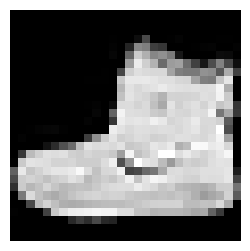

T-shirt/top:


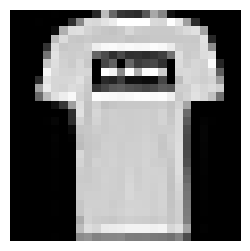

T-shirt/top:


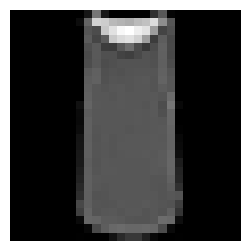

Dress:


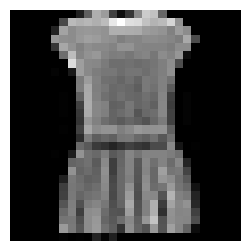

T-shirt/top:


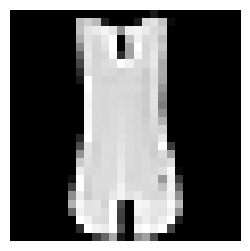

Pullover:


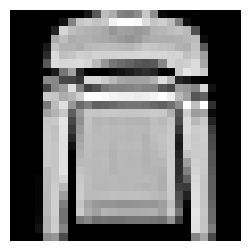

In [19]:
for i in range(6):
    print(f"{class_names[y_train[i]]}:")
    plot_greyscale(X_train[i])


#### Pre-processing

In [20]:
# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

#### Model creation / fitting

In [21]:
# Data parameters
input_shape = (28, 28, 1)

Create Keras model

In [22]:
model = Sequential([
    Input(shape=input_shape),
    Conv2D(16, kernel_size=(4, 4), strides=1, activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), strides=1, activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

Compile and build the Keras model

In [23]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,922 (50.48 KB)

 Trainable params: 12,922 (50.48 KB)

 Non-trainable params: 0 (0.00 B)

Fit the model

In [25]:
epochs = 8
batch_size = 128

trained = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.3)

Epoch 1/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5724 - loss: 1.2318 - val_accuracy: 0.8151 - val_loss: 0.5183
Epoch 2/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7953 - loss: 0.5536 - val_accuracy: 0.8352 - val_loss: 0.4595
Epoch 3/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8227 - loss: 0.4885 - val_accuracy: 0.8507 - val_loss: 0.4178
Epoch 4/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8374 - loss: 0.4573 - val_accuracy: 0.8593 - val_loss: 0.3944
Epoch 5/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8483 - loss: 0.4315 - val_accuracy: 0.8704 - val_loss: 0.3734
Epoch 6/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8529 - loss: 0.4134 - val_accuracy: 0.8727 - val_loss: 0.3618
Epoch 7/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8613 - loss: 0.3964 - val_accuracy: 0.8754 - val_loss: 0.3517
Epoch 8/8
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8642 - loss: 0.3826 - val_accuracy: 0.

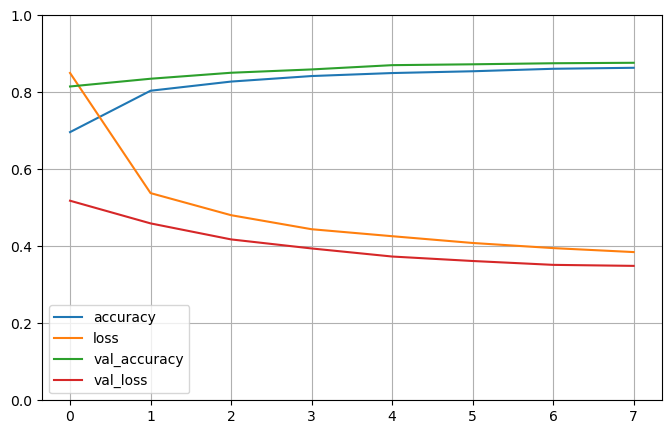

In [26]:
plot_history(trained.history)

In [27]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {score[0]:.3f}")
print(f"Test accuracy: {score[1]:.3f}")

Test loss: 0.361
Test accuracy: 0.872


#### Check some examples

In [28]:
SAMPLE_INDEX = 4

In [29]:
my_image = X_test[SAMPLE_INDEX]

predictions = model.predict(np.array([my_image]))
my_prediction = predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step



 This image is actually 'Shirt'


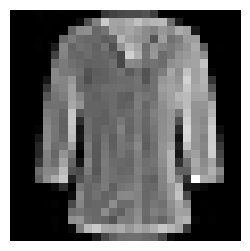


 Predicted a 'Shirt' with 76.71% probability.


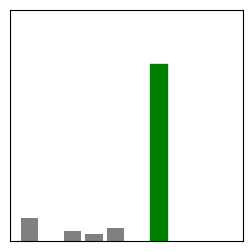

In [30]:
print(f"\n This image is actually '{class_names[y_test[SAMPLE_INDEX]]}'")

# probability
pred_class = np.argmax(my_prediction)
pred_class_name = class_names[pred_class]

# class
pred_probability = my_prediction[pred_class]

plot_greyscale(my_image)
print(f"\n Predicted a '{pred_class_name}' with {100 * pred_probability:.2f}% probability.")

plot_value_array(my_prediction, pred_class, y_test[SAMPLE_INDEX])

In [31]:
# explain predictions of the model on four images
explainer = shap.DeepExplainer(model, X_train[0:200])

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: keras_tensor. Received: the structure of inputs=['*']
  warnings.warn(


In [32]:
SAMPLE_LIST = [0, 11, 2, 5, 19]

In [33]:
shap_values = explainer.shap_values(X_test[SAMPLE_LIST])

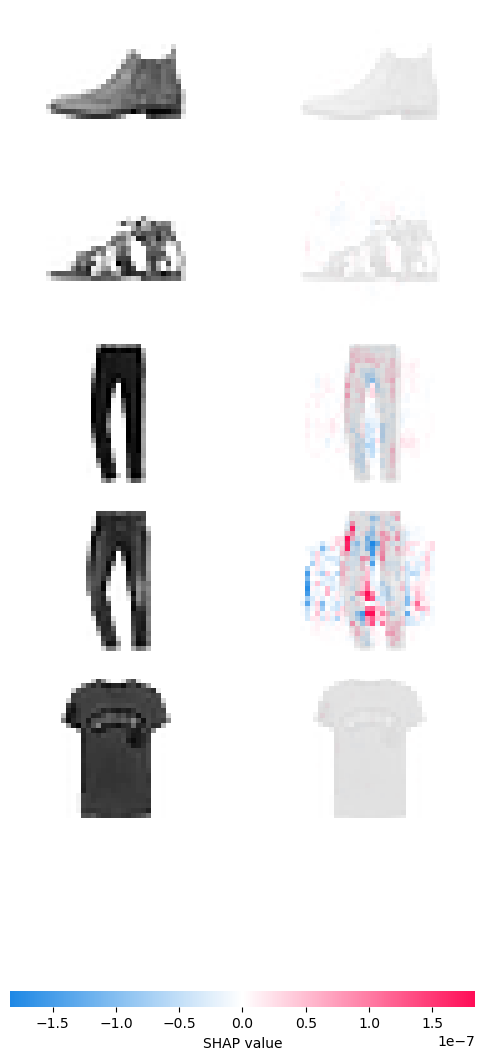

In [34]:
# plot the feature attributions
shap.image_plot(shap_values, -X_test[SAMPLE_LIST])

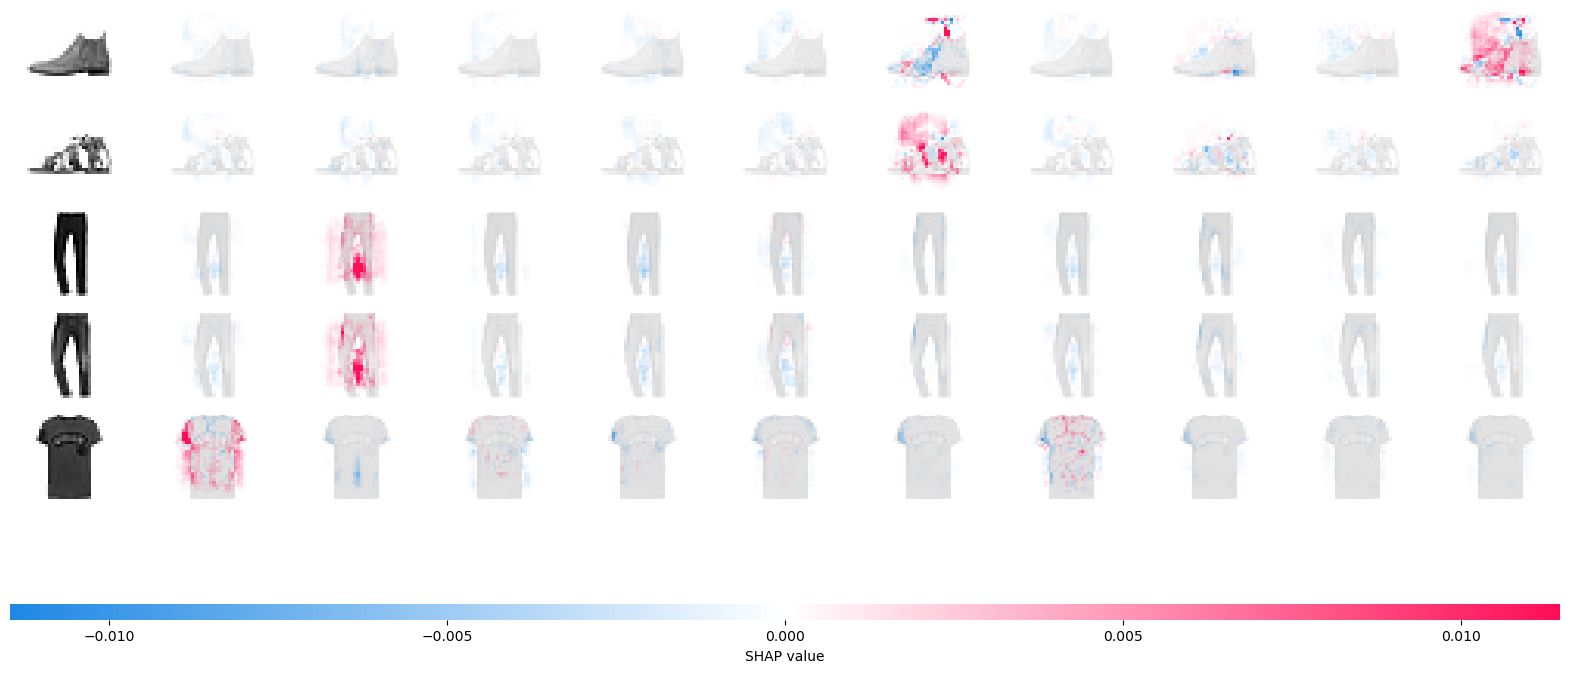

In [89]:
# plot the feature attributions
shap.image_plot(shap_values, -X_test[SAMPLE_LIST])

In [90]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']